# Data Drift Simulation

Simulación de Data Drift con Detección de Pérdida de Performance


Instrucciones:

* Genera un conjunto de datos de monitoreo con una distribución alterada (p. ej., desplazamiento de medias, feature faltantes, cambio estacional) respecto del set de validación.

* Evalúa métricas de desempeño en este nuevo set y compáralas con la línea base.

* Registra resultados y/o gráficos para observar el drift, implementa umbrales y criterios de alerta y una acción propuesta (p. ej., revisión del feature pipeline o retrain).

**Importancia**: Detectar data drift a tiempo evita degradación en producción y habilita estrategias de mantenimiento proactivo del modelo.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from alibi_detect.cd import KSDrift

from mlops_online_news_popularity.preprocessing import DataProcessor

In [2]:
# 1. Preprocess data
processor = DataProcessor(filepath='../data/raw/online_news_original.csv')
processor.process()


PHASE 1: LOADING AND CLEANING DATA
Loading data from: ../data/raw/online_news_original.csv
Loaded shape: (39644, 61)
Limpiando clave primaria 'url'...
Forzando columnas a tipo numérico...
Aplicando reglas de negocio...
Normalizando columnas LDA...
Cleaned shape: (39644, 61)

PHASE 2: FEATURE ENGINEERING
Target: shares
Target shape: (39644,)
Target stats: min=1.00, median=1400.00, max=843300.00, skew=33.96

Dropped non-predictive columns: ['url', 'timedelta']
Numeric features: 58
Columnas binarias identificadas: 14
Columnas numéricas no binarias: 44

Feature classification:
  Binary columns: 14
  Non-binary columns: 44
Total features after engineering: 58

PHASE 3: TRAIN/VAL/TEST SPLIT
Split proportions: 70% / 15% / 15%
Train set: (27750, 58)
Val set:   (5947, 58)
Test set:  (5947, 58)

PHASE 4: HANDLING HIGH CORRELATION
Correlation threshold: 0.9
  High correlation (1.000): n_non_stop_words <-> n_non_stop_unique_tokens
    → Dropping 'n_non_stop_words' (avg_corr=0.039)
  High correlat

In [3]:
X_train = pd.DataFrame(processor.X_train)
X_test = pd.DataFrame(processor.X_test)
X_val = pd.DataFrame(processor.X_val)

y_train = processor.y_train
y_test = processor.y_test
y_val = processor.y_val


clf = RandomForestRegressor(n_estimators=10, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
def analizar_sensibilidad_drift(model, X_train, X_test, y_test, feature_list, shift_list, umbral):

    """
    Analiza el impacto del Data Drift en una lista de features bajo diferentes magnitudes de desplazamiento.
    
    Parámetros:
    - model: El modelo entrenado (debe tener .predict y .feature_importances_).
    - X_train: DataFrame de entrenamiento (referencia para el detector).
    - X_test: DataFrame de validación/test (base para generar datos sintéticos).
    - y_test: Etiquetas verdaderas de X_test.
    - feature_list: Lista de nombres de columnas a analizar (ej. ['n_tokens_content', 'num_hrefs']).
    - shift_list: Lista de factores de desplazamiento (ej. [0.1, 0.5, 2.0] donde 0.1 es +10%).
    - umbral: Valor que levantará la advertencia de Data Drift
    """
    UMBRAL_IMPACTO_CRITICO = 15.0        # Umbral de impacto Crítico
    UMBRAL_IMPACTO_ADVERTENCIA = 5.0     # Umbral de impacto de advertencia
    
    #Calcular Línea Base (Rendimiento original)
    print("Calculando línea base...")
    y_pred_base = model.predict(X_test)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
    
    # Preparar Importancias de Features
    feature_importances = dict(zip(X_train.columns, model.feature_importances_))
    
    # Inicializar Detector de Drift
    # Usamos corrección de Bonferroni para ser estrictos estadísticamente
    cd = KSDrift(X_train.values, p_val=0.05, correction='bonferroni')
    
    print(f"RMSE Base del Modelo: {baseline_rmse:.4f}")
    print("-" * 80)

    # Iterar por cada Feature solicitada
    for feature in feature_list:
        if feature not in X_train.columns:
            print(f"⚠️ Feature '{feature}' no encontrada. Saltando...")
            continue
        
        if feature_importances.get(feature, 0) < 0.05:
            continue

        importance = feature_importances.get(feature, 0)
        col_idx = list(X_train.columns).index(feature)
        
        print(f"\n📊 ANALIZANDO: {feature.upper()}")
        print(f"   Importancia para el modelo: {importance:.4f}")
        
        # Configurar Gráfico
        plt.figure(figsize=(12, 6))
        # Graficar distribución original
        sns.kdeplot(X_test[feature], label='Original (Test)', color='black', fill=True, alpha=0.1, linewidth=2)
        
        results_table = []

        std_dev = X_train[feature].std()

        # Iterar por cada magnitud de desplazamiento (Shift)

        for strength in shift_list:

            # Crear copia para no modificar el original
            X_synthetic = X_test.copy()

            # Tomamos una muestra aleatoria del 50% de los datos de test
            indices_drift = X_synthetic.sample(frac=0.5, random_state=42).index

            # Aplicamos el shift solo a esa muestra
            shift_amount = strength * std_dev
            X_synthetic.loc[indices_drift, feature] = X_synthetic.loc[indices_drift, feature] + shift_amount
                    
            # Detección Estadística (Alibi Detect)
            # Pasamos todo el dataset, el detector analiza columna por columna
            preds = cd.predict(X_synthetic.values, return_p_val=True)
            p_value = preds['data']['p_val'][col_idx]
            is_drift = p_value < umbral # Umbral típico
            
            # Evaluación de Impacto en Performance
            y_pred_drift = model.predict(X_synthetic)
            current_rmse = np.sqrt(mean_squared_error(y_test, y_pred_drift))
            
            # Calcular el impacto del Performance
            error_increase = ((current_rmse - baseline_rmse) / baseline_rmse) * 100

            accion_propuesta = "🟢 OPERACIÓN NOMINAL"

            if is_drift and error_increase > UMBRAL_IMPACTO_CRITICO:
                accion_propuesta = "🔴 CRÍTICA: REENTRENAMIENTO AUTOMÁTICO"
            elif is_drift and error_increase > UMBRAL_IMPACTO_ADVERTENCIA:
                accion_propuesta = "🟠 ALTA: REVISIÓN MANUAL"
            elif is_drift:
                accion_propuesta = "🟡 INFO: MONITOREAR"
            elif not is_drift and error_increase > UMBRAL_IMPACTO_CRITICO:
                accion_propuesta = "🟣 CRÍTICA: CONCEPT DRIFT DETECTADO"
            
            # Guardar resultados
            drift_icon = "🚨 SÍ" if is_drift else "✅ NO"
            results_table.append([strength, drift_icon, f"{p_value:.4f}", f"{current_rmse:.2f}", f"+{error_increase:.2f}%", accion_propuesta])
            
            # Añadir curva al gráfico
            sns.kdeplot(X_synthetic[feature], label=f'Shift {strength} (Err: +{error_increase:.1f}%)', linewidth=1.5)

        # Finalizar Gráfico
        plt.title(f"Distribución de '{feature}' con Drift Simulado\nImportancia del Modelo: {importance:.4f}")
        plt.xlabel(feature)
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Imprimir Tabla de Resultados
        print(f"{'Shift':<10} | {'¿Hay Drift?':<13} | {'P-Value':<10} | {'RMSE':<10} | {'Impacto (Error)':<15} | {'Accion':<20}")
        print("-" * 90)
        for row in results_table:
            print(f"{str(row[0]):<10} | {str(row[1]):<12} | {str(row[2]):<10} | {str(row[3]):<10} | {str(row[4]):<15} | {str(row[5]):<20}")
        print("\n")

Calculando línea base...
RMSE Base del Modelo: 10838.0436
--------------------------------------------------------------------------------

📊 ANALIZANDO: N_TOKENS_CONTENT
   Importancia para el modelo: 0.1137


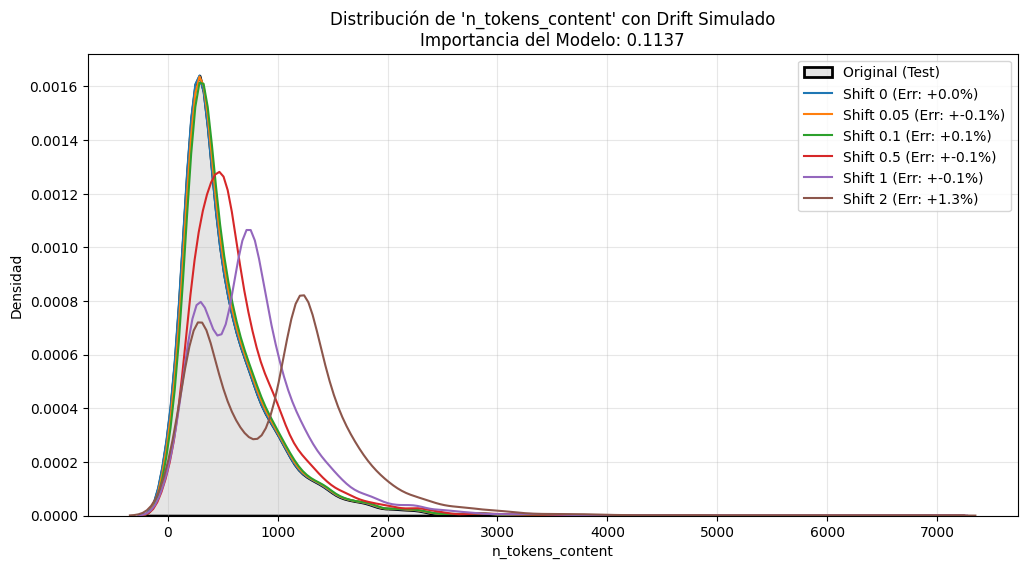

Shift      | ¿Hay Drift?   | P-Value    | RMSE       | Impacto (Error) | Accion              
------------------------------------------------------------------------------------------
0          | 🚨 SÍ         | 0.0004     | 10838.04   | +0.00%          | 🟡 INFO: MONITOREAR  
0.05       | 🚨 SÍ         | 0.0037     | 10828.99   | +-0.08%         | 🟡 INFO: MONITOREAR  
0.1        | 🚨 SÍ         | 0.0000     | 10846.03   | +0.07%          | 🟡 INFO: MONITOREAR  
0.5        | 🚨 SÍ         | 0.0000     | 10824.89   | +-0.12%         | 🟡 INFO: MONITOREAR  
1          | 🚨 SÍ         | 0.0000     | 10826.57   | +-0.11%         | 🟡 INFO: MONITOREAR  
2          | 🚨 SÍ         | 0.0000     | 10982.46   | +1.33%          | 🟡 INFO: MONITOREAR  



📊 ANALIZANDO: KW_AVG_AVG
   Importancia para el modelo: 0.1087


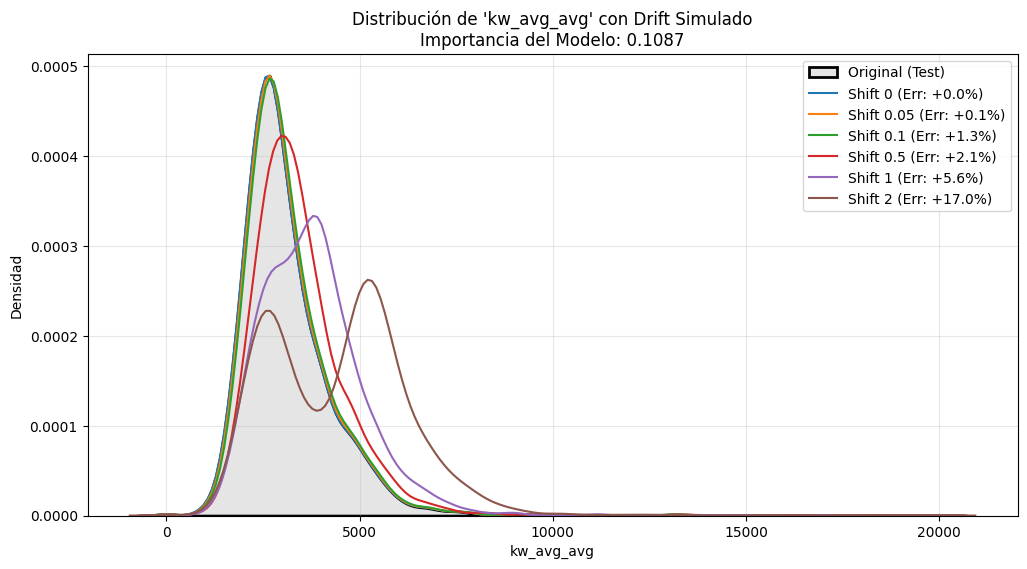

Shift      | ¿Hay Drift?   | P-Value    | RMSE       | Impacto (Error) | Accion              
------------------------------------------------------------------------------------------
0          | ✅ NO         | 0.2880     | 10838.04   | +0.00%          | 🟢 OPERACIÓN NOMINAL 
0.05       | ✅ NO         | 0.1753     | 10849.50   | +0.11%          | 🟢 OPERACIÓN NOMINAL 
0.1        | 🚨 SÍ         | 0.0000     | 10981.49   | +1.32%          | 🟡 INFO: MONITOREAR  
0.5        | 🚨 SÍ         | 0.0000     | 11062.69   | +2.07%          | 🟡 INFO: MONITOREAR  
1          | 🚨 SÍ         | 0.0000     | 11440.66   | +5.56%          | 🟠 ALTA: REVISIÓN MANUAL
2          | 🚨 SÍ         | 0.0000     | 12683.62   | +17.03%         | 🔴 CRÍTICA: REENTRENAMIENTO AUTOMÁTICO



📊 ANALIZANDO: SELF_REFERENCE_AVG_SHARESS
   Importancia para el modelo: 0.0513


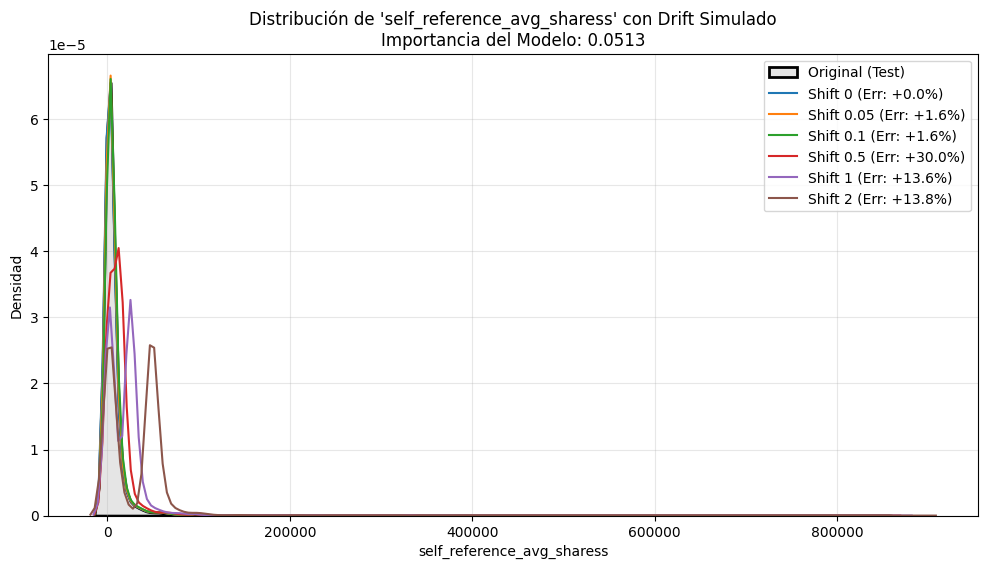

Shift      | ¿Hay Drift?   | P-Value    | RMSE       | Impacto (Error) | Accion              
------------------------------------------------------------------------------------------
0          | ✅ NO         | 0.6065     | 10838.04   | +0.00%          | 🟢 OPERACIÓN NOMINAL 
0.05       | 🚨 SÍ         | 0.0000     | 11012.06   | +1.61%          | 🟡 INFO: MONITOREAR  
0.1        | 🚨 SÍ         | 0.0000     | 11012.82   | +1.61%          | 🟡 INFO: MONITOREAR  
0.5        | 🚨 SÍ         | 0.0000     | 14089.58   | +30.00%         | 🔴 CRÍTICA: REENTRENAMIENTO AUTOMÁTICO
1          | 🚨 SÍ         | 0.0000     | 12311.21   | +13.59%         | 🟠 ALTA: REVISIÓN MANUAL
2          | 🚨 SÍ         | 0.0000     | 12334.66   | +13.81%         | 🟠 ALTA: REVISIÓN MANUAL



📊 ANALIZANDO: LDA_00
   Importancia para el modelo: 0.0940


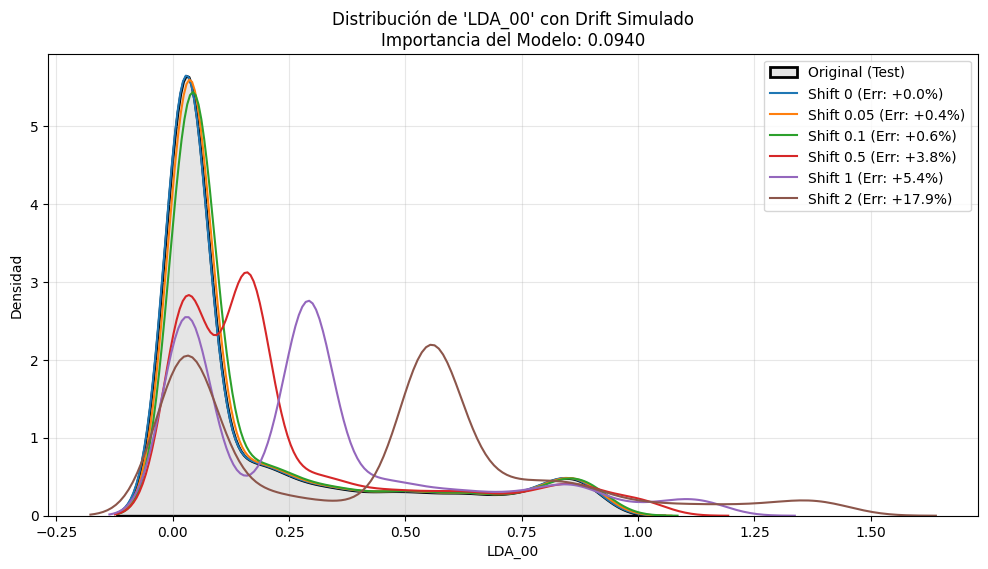

Shift      | ¿Hay Drift?   | P-Value    | RMSE       | Impacto (Error) | Accion              
------------------------------------------------------------------------------------------
0          | ✅ NO         | 0.3633     | 10838.04   | +0.00%          | 🟢 OPERACIÓN NOMINAL 
0.05       | 🚨 SÍ         | 0.0000     | 10878.04   | +0.37%          | 🟡 INFO: MONITOREAR  
0.1        | 🚨 SÍ         | 0.0000     | 10898.11   | +0.55%          | 🟡 INFO: MONITOREAR  
0.5        | 🚨 SÍ         | 0.0000     | 11246.26   | +3.77%          | 🟡 INFO: MONITOREAR  
1          | 🚨 SÍ         | 0.0000     | 11422.48   | +5.39%          | 🟠 ALTA: REVISIÓN MANUAL
2          | 🚨 SÍ         | 0.0000     | 12780.00   | +17.92%         | 🔴 CRÍTICA: REENTRENAMIENTO AUTOMÁTICO



📊 ANALIZANDO: LDA_04
   Importancia para el modelo: 0.0564


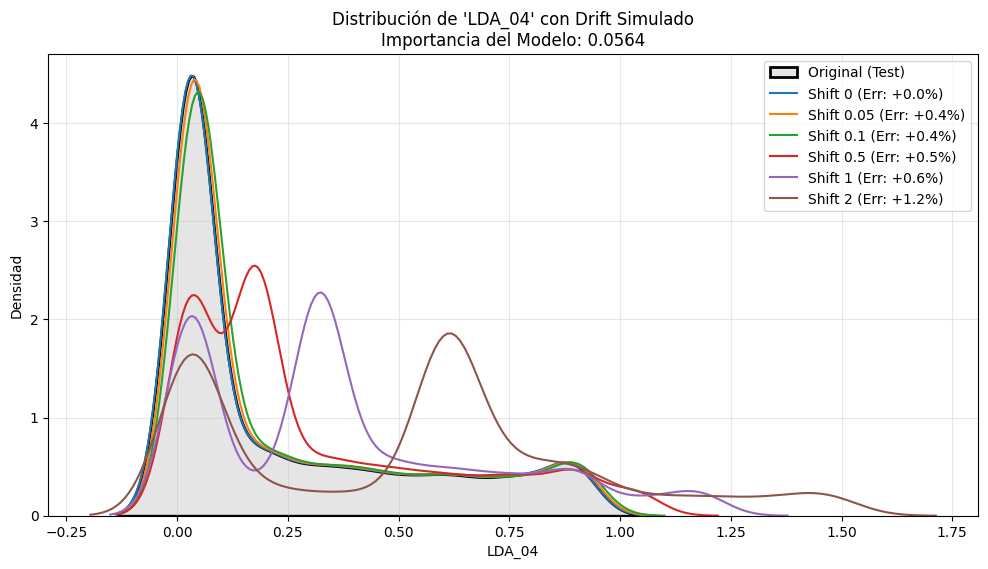

Shift      | ¿Hay Drift?   | P-Value    | RMSE       | Impacto (Error) | Accion              
------------------------------------------------------------------------------------------
0          | ✅ NO         | 0.9368     | 10838.04   | +0.00%          | 🟢 OPERACIÓN NOMINAL 
0.05       | 🚨 SÍ         | 0.0000     | 10883.39   | +0.42%          | 🟡 INFO: MONITOREAR  
0.1        | 🚨 SÍ         | 0.0000     | 10885.24   | +0.44%          | 🟡 INFO: MONITOREAR  
0.5        | 🚨 SÍ         | 0.0000     | 10891.91   | +0.50%          | 🟡 INFO: MONITOREAR  
1          | 🚨 SÍ         | 0.0000     | 10908.48   | +0.65%          | 🟡 INFO: MONITOREAR  
2          | 🚨 SÍ         | 0.0000     | 10966.15   | +1.18%          | 🟡 INFO: MONITOREAR  




In [5]:
# Shift list
lista_shifts = [0, 0.05, 0.1, 0.5, 1, 2]

# Features to test
lista_features = processor.cols_no_bin

analizar_sensibilidad_drift(
    model=clf,              # Tu modelo entrenado
    X_train=X_train,        # Tu DataFrame de entrenamiento (pandas)
    X_test=X_test,          # Tu DataFrame de test (pandas)
    y_test=y_test,          # Tus etiquetas reales
    feature_list=lista_features,
    shift_list=lista_shifts,
    umbral = 0.05
)